In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from tqdm import tqdm

os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

from processing import TextProcessingPipeline, ImageProcessingPipeline

print("Backend Keras configuré sur :", keras.backend.backend())
print("GPU disponible pour PyTorch :", torch.cuda.is_available())

Backend Keras configuré sur : torch
GPU disponible pour PyTorch : True


In [2]:
text_pipe = TextProcessingPipeline()
TOKEN_FILE_PATH = "../data/Flickr8k.token.txt"
descriptions = text_pipe.load_raw_descriptions(TOKEN_FILE_PATH)
descriptions = text_pipe.clean_descriptions_base(descriptions)

img_pipe = ImageProcessingPipeline(target_size=(299, 299))
FEATURES_PICKLE_PATH = "../data/features_inceptionv3.pkl"

if os.path.exists(FEATURES_PICKLE_PATH):
    image_features = img_pipe.load_features(FEATURES_PICKLE_PATH)
    print(f"Dictionnaires chargés : {len(descriptions)} descriptions et {len(image_features)} features d'images.")
else:
    print(f"Erreur : Le fichier de cache '{FEATURES_PICKLE_PATH}' n'a pas été trouvé. Lancez main.py d'abord.")

Dictionnaires chargés : 8092 descriptions et 8091 features d'images.


In [3]:
with open("../tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

model = keras.models.load_model("../data/flickr8k_caption_generator_inceptionv3.keras")

max_length = 37

print("Modèle et Tokenizer chargés avec succès !")

Modèle et Tokenizer chargés avec succès !


In [4]:
def generate_caption_optimized(model, tokenizer, index_to_word, feature_vector, max_length, text_pipe):
    """
    Génère une légende de manière optimisée (Greedy Search) en utilisant 
    un dictionnaire inverse index_to_word pré-calculé et aligné sur l'entraînement.
    """
    in_text = text_pipe.start_token
    feature_vector = np.array(feature_vector).reshape(1, -1)
    
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # CORRECTION : On retire padding='post' pour utiliser le padding par défaut ('pre') identique à l'entraînement
        sequence = pad_sequences([sequence], maxlen=max_length)
        
        yhat = model.predict([feature_vector, sequence], verbose=0)
        idx = np.argmax(yhat)

        word = index_to_word.get(idx)
        
        if word is None:
            break
            
        in_text += ' ' + word
        
        if word == text_pipe.end_token:
            break

    # Nettoyage des tokens de contrôle pour le calcul exact des métriques
    final_caption = ' '.join(
        w for w in in_text.split() 
        if w not in (text_pipe.start_token, text_pipe.end_token, 'unk')
    )
    return final_caption

In [5]:
TEST_SPLIT_PATH = "../data/Flickr_8k.testImages.txt"

def load_test_ids(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        lines = f.read().strip().split('\n')
    return set(line.split('.')[0] for line in lines if line.strip())

test_ids = load_test_ids(TEST_SPLIT_PATH)

actual_references = []
predicted_captions = []

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
total_rouge1, total_rougeL, evaluated_count = 0, 0, 0

index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}

print(f"Lancement de l'évaluation sur les {len(test_ids)} images du test set...")

for img_id in tqdm(descriptions.keys()):
    if img_id not in test_ids or img_id not in image_features:
        continue
        
    feature_vector = image_features[img_id]

    pred_sentence = generate_caption_optimized(
        model=model, 
        tokenizer=tokenizer, 
        index_to_word=index_to_word,
        feature_vector=feature_vector, 
        max_length=max_length,
        text_pipe=text_pipe
    )
    
    img_references = []
    raw_references_sentences = [] 
    
    for desc in descriptions[img_id]:
        clean_desc = ' '.join(w for w in desc.split() if w not in (text_pipe.start_token, text_pipe.end_token))
        img_references.append(clean_desc.split())
        raw_references_sentences.append(clean_desc)
        
    actual_references.append(img_references)
    predicted_captions.append(pred_sentence.split())

    best_r1, best_rl = 0, 0
    for ref in raw_references_sentences:
        scores = scorer.score(ref, pred_sentence)
        best_r1 = max(best_r1, scores['rouge1'].fmeasure)
        best_rl = max(best_rl, scores['rougeL'].fmeasure)
        
    total_rouge1 += best_r1
    total_rougeL += best_rl
    evaluated_count += 1

print(f"\nÉvaluation terminée sur {evaluated_count} images.")

Lancement de l'évaluation sur les 1000 images du test set...


100%|██████████| 8092/8092 [09:10<00:00, 14.71it/s]


Évaluation terminée sur 1000 images.


In [6]:
print(f"=== RAPPORT SCORES SUR LE TEST SET ({evaluated_count} IMAGES) ===\n")

bleu1 = corpus_bleu(actual_references, predicted_captions, weights=(1.0, 0, 0, 0))
bleu2 = corpus_bleu(actual_references, predicted_captions, weights=(0.5, 0.5, 0, 0))
bleu3 = corpus_bleu(actual_references, predicted_captions, weights=(0.33, 0.33, 0.33, 0))
bleu4 = corpus_bleu(actual_references, predicted_captions, weights=(0.25, 0.25, 0.25, 0.25))

avg_rouge1 = total_rouge1 / evaluated_count
avg_rougeL = total_rougeL / evaluated_count

# --- Affichage des résultats ---
print("\n" + "="*40)
print("         RÉSULTATS DES MÉTRIQUES        ")
print("="*40)
print(f"BLEU-1 (Unigrammes)  : {bleu1:.4f}  <- Fidélité du vocabulaire")
print(f"BLEU-2 (Bigrammes)   : {bleu2:.4f}  <- Cohérence locale (paires)")
print(f"BLEU-3 (Trigrammes)  : {bleu3:.4f}  <- Groupes de 3 mots")
print(f"BLEU-4 (4-grammes)   : {bleu4:.4f}  <- Fluidité syntaxique globale")
print("-"*40)
print(f"ROUGE-1 (F-measure)  : {avg_rouge1:.4f}")
print(f"ROUGE-L (F-measure)  : {avg_rougeL:.4f}")
print("="*40)

=== RAPPORT SCORES SUR LE TEST SET (1000 IMAGES) ===


         RÉSULTATS DES MÉTRIQUES        
BLEU-1 (Unigrammes)  : 0.5569  <- Fidélité du vocabulaire
BLEU-2 (Bigrammes)   : 0.3709  <- Cohérence locale (paires)
BLEU-3 (Trigrammes)  : 0.2376  <- Groupes de 3 mots
BLEU-4 (4-grammes)   : 0.1479  <- Fluidité syntaxique globale
----------------------------------------
ROUGE-1 (F-measure)  : 0.4571
ROUGE-L (F-measure)  : 0.4258


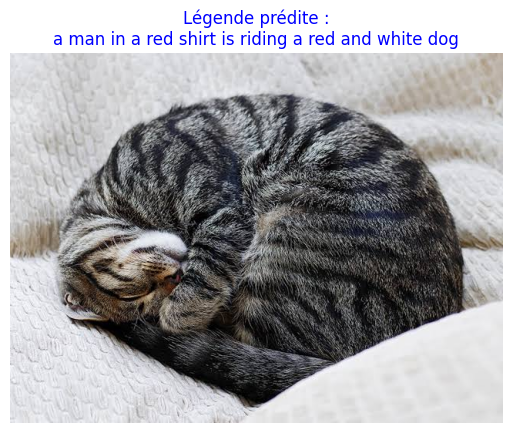

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_inception_inference = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=True)
_inception_inference.aux_logits = False
_inception_inference.AuxLogits = None
_inception_inference.fc = torch.nn.Identity()
_inception_inference = _inception_inference.to(device)
_inception_inference.eval()

_preprocess_inference = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def pipeline_prediction_nouvelle_image(image_path):
    img_pil = Image.open(image_path).convert('RGB')
    tensor_img = _preprocess_inference(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        feature_vector = _inception_inference(tensor_img).cpu().numpy().flatten()

    legende = generate_caption_optimized(
        model=model,
        tokenizer=tokenizer,
        index_to_word=index_to_word,
        feature_vector=feature_vector,
        max_length=max_length,
        text_pipe=text_pipe
    )

    plt.imshow(img_pil)
    plt.title(f"Légende prédite :\n{legende}", fontsize=12, color='blue')
    plt.axis('off')
    plt.show()

    return legende

CHEMIN_TEST = "../data/papillon2.jpg"

if os.path.exists(CHEMIN_TEST):
    pipeline_prediction_nouvelle_image(CHEMIN_TEST)
else:
    print(f"Veuillez spécifier un chemin d'image valide dans la variable 'CHEMIN_TEST'.")